In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def Ez(z,*param):
    if modelo == 1:
        Om = param[0]
        return np.sqrt(Om*(1+z)**3 + 1 - Om)
    elif modelo == 2:
        Om, lamb = param
        return np.sqrt(3/(3-lamb**2)*Om*(1+z)**3 + (1 - 3/(3-lamb**2)*Om)**(1+z)**(lamb**2))

def Dc(z, *param):
        Ei = lambda x, y: 1/Ez(x, *param)
        #z_unique, inverse = np.unique(z, return_inverse = True)   
        #sol = solve_ivp(Ei, [0, z_unique[-1]],[0], t_eval=z_unique)
        sol = solve_ivp(Ei, [0, z[-1]],[0.0], t_eval=z)
        #return sol.y.flatten()
        return np.asarray(sol.y).flatten()

def rd(Om, h):
    #Sound horizon at the drag epoch in Mpc (fitting formula)
    return 147.05 * (Om * h**2 / 0.1432)**(-0.32)

In [45]:
#modelo = 1; Om = 0.3; h = 0.7; lamb = []
modelo = 2; Om = 0.3; h = 0.7; lamb = 0.3

zv = np.linspace(0.01,2.5,100)

rd_fid = rd(Om,h)
DM_th = 3e3/h * Dc(zv,Om,0)                                 # comoving distance [Mpc]
DH_th = 3e3/h / Ez(zv,Om,lamb)    # Hubble distance [Mpc]
DV_th = (zv * DM_th**2 * DH_th)**(1/3) 

DM/rd measurements: 6  at z = [0.51  0.706 0.934 1.321 1.484 2.33 ]
DH/rd measurements: 6  at z = [0.51  0.706 0.934 1.321 1.484 2.33 ]
DV/rd measurements: 1  at z = [0.295]


Text(0, 0.5, 'distâncias')

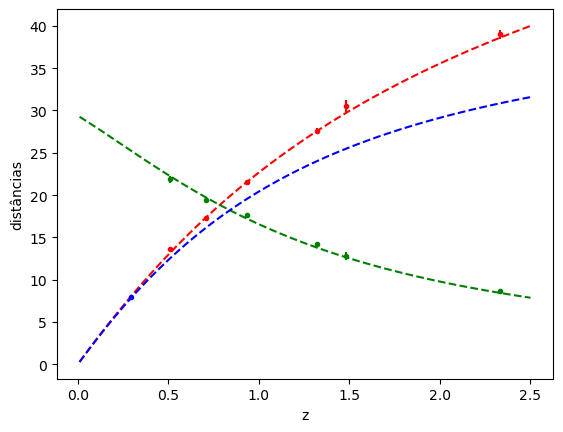

In [46]:
# Ler os dados de BAO
# columns: tracer, z_eff, observable, value, sigma
data = np.genfromtxt('../data/desi_dr2_bao.txt', dtype=None, encoding=None, names=['tracer','z','obs','val','err'])

# split by observable type
mask_DM = data['obs'] == 'DM_rd'
mask_DH = data['obs'] == 'DH_rd'
mask_DV = data['obs'] == 'DV_rd'

z_DM,  DM_obs,  dDM  = data['z'][mask_DM], data['val'][mask_DM], data['err'][mask_DM]
z_DH,  DH_obs,  dDH  = data['z'][mask_DH], data['val'][mask_DH], data['err'][mask_DH]
z_DV,  DV_obs,  dDV  = data['z'][mask_DV], data['val'][mask_DV], data['err'][mask_DV]

print(f"DM/rd measurements: {len(z_DM)}  at z = {z_DM}")
print(f"DH/rd measurements: {len(z_DH)}  at z = {z_DH}")
print(f"DV/rd measurements: {len(z_DV)}  at z = {z_DV}")

plt.plot(zv,DM_th/rd_fid,'r--')
plt.plot(zv,DH_th/rd_fid,'g--')
plt.plot(zv,DV_th/rd_fid,'b--')
plt.errorbar(z_DM, DM_obs, fmt='.', yerr=dDM, color='r')
plt.errorbar(z_DH, DH_obs, fmt='.', yerr=dDH, color='g')
plt.errorbar(z_DV, DV_obs, fmt='.', yerr=dDV, color='b')

plt.xlabel('z')
plt.ylabel('distâncias')


In [61]:
def log_likelihood_BAO(theta, zm, dm, ddm, zh, dh, ddh, zv, dv, ddv):
    
    Om, h, lamb = theta
    z = np.linspace(0.01,2.5,100)
    d_c = Dc(z,Om,lamb)
    e_z = Ez(z,Om,lamb)
    rd_fid = rd(Om,h)
    DM_th = 3e3/h * np.interp(zm,z,d_c)              # comoving distance [Mpc]
    DH_th = 3e3/h / np.interp(zh,z,e_z)    # Hubble distance [Mpc]
    DV_th = 3e3/h * (zv * np.interp(zv,z,d_c)**2 / np.interp(zv,z,e_z))**(1/3)
    
    chi2_dv = np.sum((dv - DV_th/rd_fid) ** 2 / ddv**2)
    chi2_dm = np.sum((dm - DM_th/rd_fid) ** 2 / ddm**2)
    chi2_dh = np.sum((dh - DH_th/rd_fid) ** 2 / ddh**2)
    chi2 = chi2_dv + chi2_dm + chi2_dh 
    return -0.5 * chi2

def log_prior(theta):
    Om, h, lamb = theta
    if 0.2 < Om < 0.5 and 0.5 < h < 0.9 and -0.3 < lamb < 0.3:        
        return 0.0
    return -np.inf

def log_probability(theta, zm, dm, ddm, zh, dh, ddh, zv, dv, ddv):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    lp = lp + log_likelihood_BAO(theta, zm, dm, ddm, zh, dh, ddh, zv, dv, ddv)
    return lp       

100%|██████████████████████████████████████| 5000/5000 [02:04<00:00, 40.09it/s]


(10432, 3)


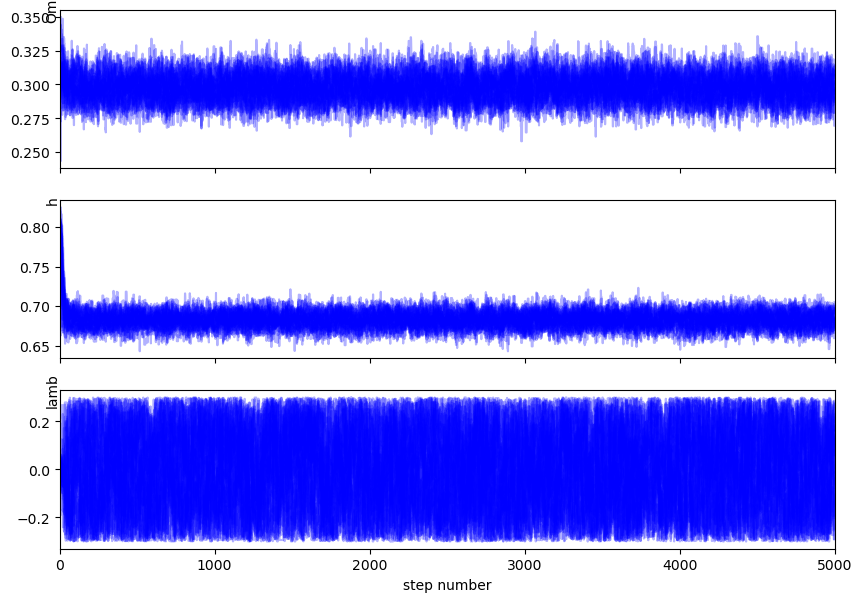

In [64]:
import emcee
#import corner
#conda install -c conda-forge getdist
from getdist import MCSamples, plots
#pip install tqdm
from tqdm.notebook import tqdm

#pontos iniciais para parameteros Om, h, lamb
fonte = np.array([0.3,0.8,0.01])

pos = fonte + 1e-2 * np.random.randn(32, 3)
#pos = fonte + 1e-2 * np.random.randn(32, 2)

nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(z_DM, DM_obs, dDM, z_DH,  DH_obs,  dDH, z_DV,  DV_obs, dDV ))
sampler.run_mcmc(pos, 5000, progress=True);

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["Om", "h", "lamb"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "b", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(0, 1)

axes[-1].set_xlabel("step number");

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

filename = 'ola_bao'
np.save(filename, samples)

Removed no burn in


Om = 0.2976\pm 0.0096
h = 0.683\pm 0.011
lamb = 0.00\pm 0.17


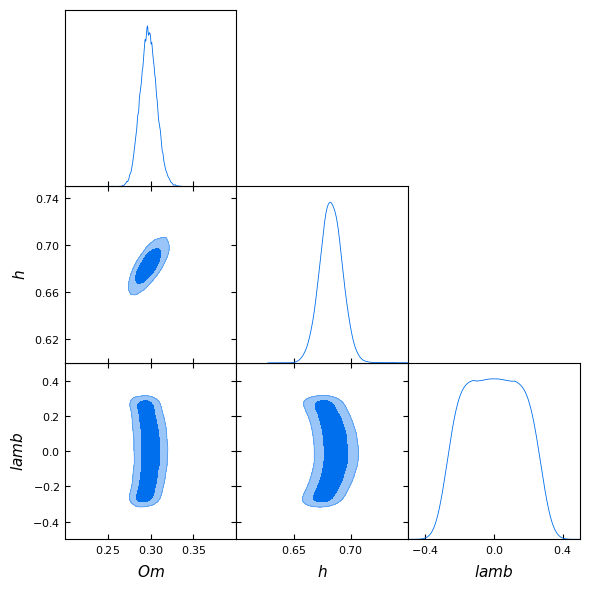

In [65]:
# use getdist  -------------------------------------------------
#
#conda install -c conda-forge getdist
samples_g = MCSamples(samples=samples, names=labels, labels=labels, settings=dict(smooth_scale_2D=1))

g = plots.get_subplot_plotter()
g.triangle_plot([samples_g], filled=True, param_limits={'lamb':(-0.5,0.5),'h':(0.6,0.75),'Om':(0.2,0.4)})

print(samples_g.getInlineLatex('Om', limit=1))
print(samples_g.getInlineLatex('h', limit=1))
print(samples_g.getInlineLatex('lamb', limit=1))